# Bab 4: Regression and Prediction

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)

## Ringkasan Bab
Regresi dipakai untuk mengukur hubungan antara sebuah **outcome** numerik dan satu atau lebih **prediktor**, baik untuk **prediksi** maupun **penjelasan**.

1. **Regresi linear sederhana.** Garis fit, metode kuadrat terkecil, dan residual.
2. **Regresi linear berganda.** Penilaian model (RMSE, $R^2$, statistik t), cross-validation, pemilihan model (AIC, stepwise), dan regresi berbobot.
3. **Prediksi dengan regresi.** Confidence interval dibanding prediction interval, dan bahaya ekstrapolasi.
4. **Variabel faktor.** Dummy/one-hot encoding, reference coding, dan faktor ordinal.
5. **Menafsirkan persamaan regresi.** Prediktor yang berkorelasi, multikolinearitas, confounder, dan interaksi.
6. **Diagnostik regresi.** Outlier, nilai berpengaruh, heteroskedastisitas, dan partial residual plot.
7. **Regresi polinomial dan spline.** Hubungan non-linear dan GAM.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import linregress
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence
from pygam import LinearGAM, s, l
import seaborn as sns
import matplotlib.pyplot as plt
from dmba import stepwise_selection, AIC_score

DATA = Path('..') / 'data'
sns.set_style('whitegrid')
%matplotlib inline

no display found. Using non-interactive Agg backend


## 1. Regresi Linear Sederhana
**Penjelasan teori.** Model ini menghubungkan satu prediktor $X$ dengan respons $Y$:
$$Y=b_0+b_1X+e$$
- $b_0$ adalah **intersep** (prediksi $Y$ saat $X=0$), dan $b_1$ adalah **slope/koefisien regresi** ($\Delta Y/\Delta X$).
- **Nilai fit** $\hat{Y}_i=\hat b_0+\hat b_1X_i$ dan **residual** $e_i=Y_i-\hat{Y}_i$.
- **Kuadrat terkecil (least squares)** memilih $\hat b_0,\hat b_1$ yang meminimalkan **jumlah kuadrat residual** $RSS=\sum e_i^2$ (OLS). Solusinya punya bentuk tertutup, tetapi sensitif terhadap outlier.
- **Korelasi dan regresi:** korelasi mengukur kekuatan hubungan linear (simetris), sedangkan regresi menggambarkan bentuk hubungannya (tidak simetris, $Y$ diprediksi dari $X$).

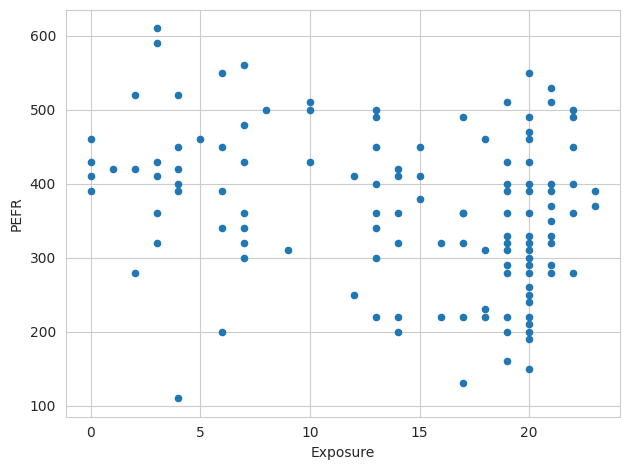

In [2]:
lung = pd.read_csv(DATA / 'LungDisease.csv')
lung.plot.scatter(x='Exposure', y='PEFR')
plt.tight_layout(); plt.show()

In [3]:
predictors = ['Exposure']
outcome = 'PEFR'
model = LinearRegression()
model.fit(lung[predictors], lung[outcome])
print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


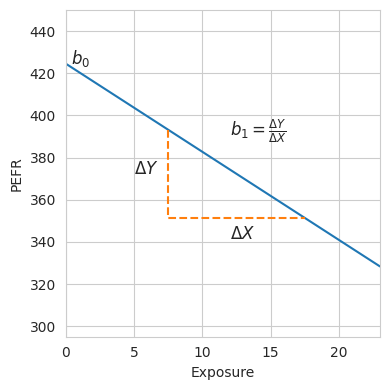

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 23); ax.set_ylim(295, 450)
ax.set_xlabel('Exposure'); ax.set_ylabel('PEFR')
ax.plot((0, 23), model.predict(pd.DataFrame({'Exposure': [0, 23]})))
ax.text(0.4, model.intercept_, r'$b_0$', size='larger')
x = pd.DataFrame({'Exposure': [7.5, 17.5]})
y = model.predict(x)
ax.plot((7.5, 7.5, 17.5), (y[0], y[1], y[1]), '--')
ax.text(5, np.mean(y), r'$\Delta Y$', size='larger')
ax.text(12, y[1] - 10, r'$\Delta X$', size='larger')
ax.text(12, 390, r'$b_1 = \frac{\Delta Y}{\Delta X}$', size='larger')
plt.tight_layout(); plt.show()

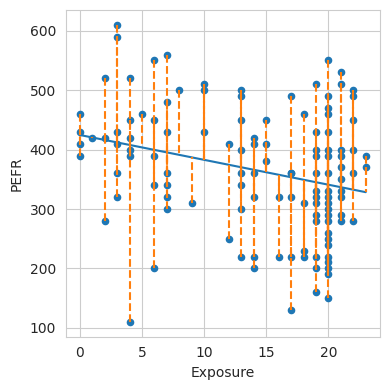

In [5]:
# Fitted values and residuals
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted
ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
ax.plot(lung.Exposure, fitted)
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted):
    ax.plot((x, x), (yactual, yfitted), '--', color='C1')
plt.tight_layout(); plt.show()

## 2. Regresi Linear Berganda
**Penjelasan teori.** Modelnya diperluas ke $p$ prediktor: $Y=b_0+b_1X_1+\dots+b_pX_p+e$. Tiap koefisien menunjukkan perubahan $Y$ untuk kenaikan satu satuan $X_j$ **dengan prediktor lain dianggap tetap**.

**Menilai model**
- **RMSE** $=\sqrt{RSS/n}$ adalah kesalahan prediksi yang umum dalam satuan $Y$ (RSE memakai $n-p-1$ sebagai pembagi).
- **$R^2$** adalah proporsi varians $Y$ yang dijelaskan model, $1-\frac{RSS}{TSS}$. **$R^2$ yang disesuaikan** memberi penalti untuk prediktor tambahan.
- **Statistik t / p-value** tiap koefisien $=\hat b_j/SE(\hat b_j)$ menjawab apakah prediktor itu signifikan setelah prediktor lain dikendalikan.
- **Cross-validation:** model dilatih pada sebagian data dan diuji pada bagian yang disisihkan, berulang kali, untuk memperkirakan error di luar sampel.

In [6]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
house = pd.read_csv(DATA / 'house_sales.csv', sep='\t')
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [7]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'
house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])
print(f'Intercept: {house_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(predictors, house_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.83060360240785
 SqFtLot: -0.06046682065307074
 Bathrooms: -19442.840398320997
 Bedrooms: -47769.9551852143
 BldgGrade: 106106.9630789808


In [8]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 261220
r2: 0.5406


In [9]:
# statsmodels gives the full statistical summary (t-stats, p-values, adj. R2)
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        11:49:54   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694

### Pemilihan Model dan Stepwise Regression
**Penjelasan teori.** Prediktor yang lebih banyak belum tentu lebih baik (**prinsip Occam**: pilih model paling sederhana yang cukup memadai). **AIC** (Akaike Information Criterion) $=2P+n\log(RSS/n)$ memberi penalti pada jumlah parameter $P$, dan makin kecil makin baik. **Stepwise selection** menambah atau membuang prediktor untuk meminimalkan AIC (*forward*, *backward*, atau *both*). **Regresi dengan penalti** (ridge, lasso) adalah alternatif yang kontinu, dibahas di bagian tambahan di akhir.

In [10]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade',
              'PropertyType', 'NbrLivingUnits', 'SqFtFinBasement', 'YrBuilt',
              'YrRenovated', 'NewConstruction']
X = pd.get_dummies(house[predictors], drop_first=True).astype(float)
X['NewConstruction'] = X['NewConstruction'].astype(int) if 'NewConstruction' in X else 0
house_full = sm.OLS(house[outcome], X.assign(const=1))
results = house_full.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        11:49:54   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving       

In [11]:
y = house[outcome]

def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(X[variables], y)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(y, [y.mean()] * len(y), model, df=1)
    return AIC_score(y, model.predict(X[variables]), model)

best_model, best_variables = stepwise_selection(X.columns, train_model, score_model, verbose=True)
print()
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt


Step: score=627784.16, add Bedrooms


Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement


Step: score=627524.98, add PropertyType_Single Family


Step: score=627524.98, unchanged None

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.27755304201577
 BldgGrade: 137159.5602262002
 YrBuilt: -3565.4249392493207
 Bedrooms: -51947.3836736137
 Bathrooms: 42396.1645277189
 PropertyType_Townhouse: 84479.16203300121
 SqFtFinBasement: 7.046974967572493
 PropertyType_Single Family: 22912.055187017613


### Regresi Berbobot
**Penjelasan teori.** Weighted least squares meminimalkan $\sum w_i e_i^2$, sehingga sebagian record punya pengaruh lebih besar. Misalnya, penjualan yang *lebih baru* dianggap lebih relevan (bobot = tahun − 2005), atau bobot mencerminkan presisi atau jumlah replikasi.

In [12]:
house['Year'] = [int(date.split('-')[0]) for date in house.DocumentDate]
house['Weight'] = house.Year - 2005

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'
house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house.Weight)
print(pd.DataFrame({'predictor': predictors,
                    'unweighted': house_lm.coef_,
                    'weighted': house_wt.coef_}))

       predictor     unweighted       weighted
0  SqFtTotLiving     228.830604     245.024089
1        SqFtLot      -0.060467      -0.292415
2      Bathrooms  -19442.840398  -26085.970109
3       Bedrooms  -47769.955185  -53608.876436
4      BldgGrade  106106.963079  115242.434726


In [13]:
residuals = pd.DataFrame({
    'abs_residual_lm': np.abs(house_lm.predict(house[predictors]) - house[outcome]),
    'abs_residual_wt': np.abs(house_wt.predict(house[predictors]) - house[outcome]),
    'Year': house['Year'],
})
print(residuals.groupby('Year').mean())

      abs_residual_lm  abs_residual_wt
Year                                  
2006    140540.303585    146557.454636
2007    147747.577959    152848.523235
2008    142086.905943    146360.411668
2009    147016.720883    151182.924825
2010    163267.674885    166364.476152
2011    169937.385744    172950.876028
2012    169506.670053    171874.424266
2013    203659.777510    206242.199403
2014    184452.840665    186668.573750
2015    172323.435147    169842.742053


## 3. Prediksi dengan Regresi
**Penjelasan teori.** Bahaya utamanya adalah **ekstrapolasi** di luar rentang data. Ada dua jenis interval:
- **Confidence interval** menggambarkan ketidakpastian *rata-rata respons* (garis regresi).
- **Prediction interval** menggambarkan ketidakpastian untuk *satu nilai baru*. Intervalnya selalu lebih lebar karena ditambah error residual yang tidak bisa dihilangkan.

In [14]:
new_house = pd.DataFrame({'SqFtTotLiving': [2000], 'SqFtLot': [8000], 'Bathrooms': [2],
                          'Bedrooms': [3], 'BldgGrade': [8]})
pred = results_small = sm.OLS(house['AdjSalePrice'], house[predictors].assign(const=1)).fit()
pr = pred.get_prediction(new_house.assign(const=1)).summary_frame(alpha=0.05)
print(pr[['mean', 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper']])

            mean  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  601966.262731  597781.365394  606151.160068  89871.941821  1.114061e+06


## 4. Variabel Faktor dalam Regresi
**Penjelasan teori.** Prediktor kategorikal diubah menjadi **variabel dummy (one-hot)**. Untuk $P$ level dipakai $P-1$ dummy, dan level yang dibuang menjadi **referensi** (kalau tidak, terjadi multikolinearitas sempurna). Koefisiennya menunjukkan selisih terhadap level referensi. Untuk faktor dengan banyak level (seperti kode pos yang ada 80 level), level-levelnya perlu **digabung**, di sini dengan mengelompokkan kode pos berdasarkan median residualnya. **Faktor ordinal** (misalnya grade) bisa diperlakukan sebagai numerik.

In [15]:
print(house.PropertyType.value_counts())
X = pd.get_dummies(house[['PropertyType']], drop_first=True).astype(float)
print(X.head())

PropertyType
Single Family    20720
Townhouse         1710
Multiplex          257
Name: count, dtype: int64
   PropertyType_Single Family  PropertyType_Townhouse
1                         0.0                     0.0
2                         1.0                     0.0
3                         1.0                     0.0
4                         1.0                     0.0
5                         1.0                     0.0


In [16]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade', 'PropertyType']
X = pd.get_dummies(house[predictors], drop_first=True).astype(float)
house_lm_factor = LinearRegression()
house_lm_factor.fit(X, house[outcome])
print(f'Intercept: {house_lm_factor.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, house_lm_factor.coef_):
    print(f' {name}: {coef}')

Intercept: -446841.366
Coefficients:
 SqFtTotLiving: 223.3736289250382
 SqFtLot: -0.07036798136811662
 Bathrooms: -15979.013473415169
 Bedrooms: -50889.7321848302
 BldgGrade: 109416.30516146179
 PropertyType_Single Family: -84678.21629549262
 PropertyType_Townhouse: -115121.9792160919


In [17]:
# Factor variable with many levels: consolidate ZIP codes
print('Number of ZIP codes:', len(house.ZipCode.unique()))
zip_groups = (pd.DataFrame({'ZipCode': house['ZipCode'],
                            'residual': house[outcome] - house_lm_factor.predict(X)})
              .groupby('ZipCode')
              .agg(count=('residual', 'size'), median_residual=('residual', 'median'))
              .reset_index()
              .sort_values('median_residual'))
zip_groups['cum_count'] = np.cumsum(zip_groups['count'])
zip_groups['ZipGroup'] = pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=False)
print(zip_groups.ZipGroup.value_counts().sort_index())

to_join = zip_groups[['ZipCode', 'ZipGroup']].set_index('ZipCode')
house = house.join(to_join, on='ZipCode')
house['ZipGroup'] = house['ZipGroup'].astype('category')

Number of ZIP codes: 80
ZipGroup
0    16
1    16
2    16
3    16
4    16
Name: count, dtype: int64


## 5. Menafsirkan Persamaan Regresi
**Penjelasan teori.**
- **Prediktor yang berkorelasi.** Kalau prediktor bergerak bersama, koefisien tiap prediktor jadi tidak stabil dan bahkan bisa bertanda "salah" (misalnya koefisien *Bedrooms* negatif setelah luas total dikendalikan).
- **Multikolinearitas.** Satu prediktor hampir merupakan kombinasi linear dari yang lain, sehingga koefisiennya tidak bisa diestimasi dengan andal. Solusinya membuang atau menggabungkan variabel, atau memakai PCA/regularisasi. Bisa dicek dengan **variance inflation factor (VIF)**.
- **Confounder.** Variabel yang terlewat dan memengaruhi prediktor sekaligus outcome akan membiaskan estimasi (lokasi adalah confounder untuk harga rumah).
- **Interaksi.** Efek satu prediktor bergantung pada prediktor lain (misalnya harga per kaki persegi berbeda antar kelompok kode pos): $SqFt\times ZipGroup$.

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xv = house[['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']].assign(const=1)
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])], index=Xv.columns)
print(vif.drop('const'))

SqFtTotLiving    4.218067
SqFtLot          1.047567
Bathrooms        2.576864
Bedrooms         1.685140
BldgGrade        2.659926
dtype: float64


In [19]:
model = smf.ols(formula='AdjSalePrice ~ SqFtTotLiving*ZipGroup + SqFtLot + Bathrooms + '
                        'Bedrooms + BldgGrade + PropertyType', data=house)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     3236.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        11:49:55   Log-Likelihood:            -3.1101e+05
No. Observations:               22687   AIC:                         6.221e+05
Df Residuals:                   22671   BIC:                         6.222e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

## 6. Diagnostik Regresi
**Penjelasan teori.**
- **Outlier.** Record dengan residual besar, dinilai lewat **residual terstandar (studentized)**, yaitu residual dibagi standard error-nya. Nilai mutlak di atas sekitar 3 perlu diperiksa.
- **Nilai berpengaruh (influential).** Titik yang kalau dibuang mengubah hasil fit secara berarti. **Hat-value** (leverage) mengukur seberapa ekstrem nilai prediktornya, dan **Cook's distance** menggabungkan leverage dengan besar residual.
- **Heteroskedastisitas.** Varians residual tidak konstan (misalnya error lebih besar untuk rumah mahal). Ini tanda ada prediktor yang terlewat atau data perlu ditransformasi. Dampaknya lebih besar ke standard error dan p-value daripada ke prediksi.
- **Residual tidak normal.** Tidak terlalu bermasalah untuk sampel besar, tetapi ekor yang tebal bisa menandakan adanya outlier.
- **Partial residual plot.** Residual ditambah kontribusi satu prediktor, diplot terhadap prediktor itu. Berguna untuk melihat apakah hubungannya benar-benar linear.

In [20]:
house_98105 = house.loc[house['ZipCode'] == 98105, :]
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'
y = house_98105[outcome]
model98105 = sm.OLS(y, house_98105[predictors].assign(const=1))
result_98105 = model98105.fit()
print(result_98105.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          1.69e-103
Time:                        11:49:55   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   209.6023     24.408      8.587

In [21]:
# Outliers: studentized residuals
influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal
print('Min / max studentized residual:', sresiduals.min(), sresiduals.max())
idx = sresiduals.idxmin()
print(idx, sresiduals[idx])
print(house_98105.loc[idx, [outcome, *predictors]])

Min / max studentized residual: -4.326731804078562 5.4081045856896806
24333 -4.326731804078562
AdjSalePrice     119748.0
SqFtTotLiving      2900.0
SqFtLot            7276.0
Bathrooms             3.0
Bedrooms              6.0
BldgGrade             7.0
Name: 24333, dtype: float64


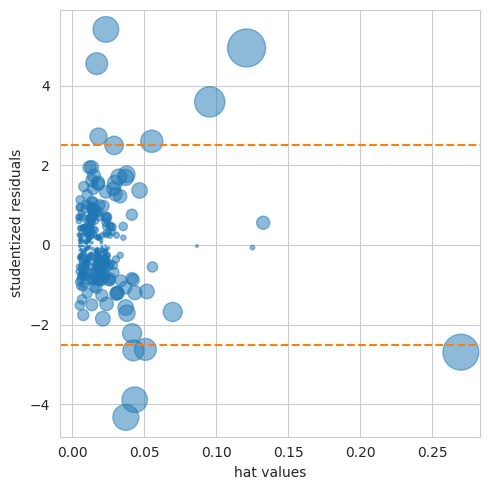

In [22]:
# Influential values: leverage, residuals, Cook's distance (bubble size)
influence = OLSInfluence(result_98105)
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle='--', color='C1'); ax.axhline(2.5, linestyle='--', color='C1')
ax.scatter(influence.hat_matrix_diag, influence.resid_studentized_internal,
           s=1000 * np.sqrt(influence.cooks_distance[0]), alpha=0.5)
ax.set_xlabel('hat values'); ax.set_ylabel('studentized residuals')
plt.tight_layout(); plt.show()

In [23]:
# Refit without the most influential points
mask = [dist < .08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]
ols_infl = sm.OLS(house_infl[outcome], house_infl[predictors].assign(const=1))
result_infl = ols_infl.fit()
print(pd.DataFrame({'Original': result_98105.params, 'Influential Removed': result_infl.params}))

                    Original  Influential Removed
SqFtTotLiving     209.602346           230.052569
SqFtLot            38.933315            33.141600
Bathrooms        2282.264145        -16131.879785
Bedrooms       -26320.268796        -22887.865318
BldgGrade      130000.099737        114870.559737
const         -772549.862447       -647137.096716


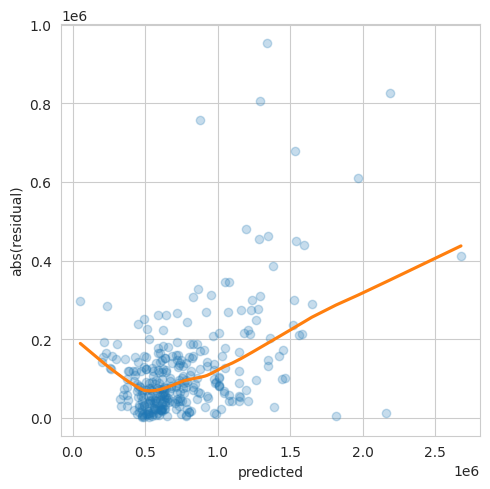

In [24]:
# Heteroskedasticity
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid),
            scatter_kws={'alpha': 0.25}, line_kws={'color': 'C1'}, lowess=True, ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('abs(residual)')
plt.tight_layout(); plt.show()

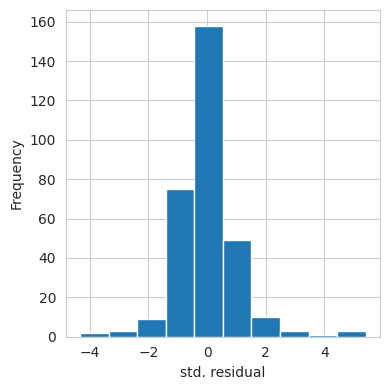

In [25]:
fig, ax = plt.subplots(figsize=(4, 4))
pd.Series(influence.resid_studentized_internal).hist(ax=ax)
ax.set_xlabel('std. residual'); ax.set_ylabel('Frequency')
plt.tight_layout(); plt.show()

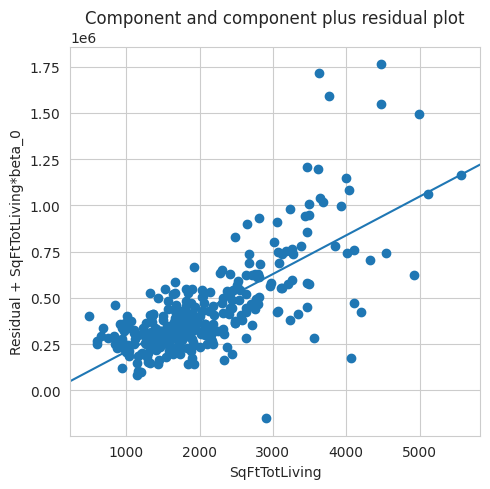

In [26]:
# Partial residual plot for a linear model
fig, ax = plt.subplots(figsize=(5, 5))
sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=ax)
plt.tight_layout(); plt.show()

## 7. Regresi Polinomial dan Spline
**Penjelasan teori.** Hubungan antar variabel sering kali melengkung.
- **Regresi polinomial** menambahkan pangkat dari prediktor ($X$, $X^2$, dan seterusnya). Modelnya tetap *linear terhadap koefisien*.
- **Spline** memasang polinomial per segmen yang disambung mulus di titik **knot**, sehingga terhindar dari perilaku liar polinomial berderajat tinggi.
- **Generalized additive model (GAM)** mengotomatiskan pemasangan spline untuk tiap prediktor: $Y=b_0+f_1(X_1)+\dots+f_p(X_p)+e$, dengan tingkat kehalusan dipilih lewat cross-validation.

In [27]:
model_poly = smf.ols(formula='AdjSalePrice ~ SqFtTotLiving + np.power(SqFtTotLiving, 2) + '
                             'SqFtLot + Bathrooms + Bedrooms + BldgGrade', data=house_98105)
result_poly = model_poly.fit()
print(result_poly.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          9.95e-106
Time:                        11:49:55   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

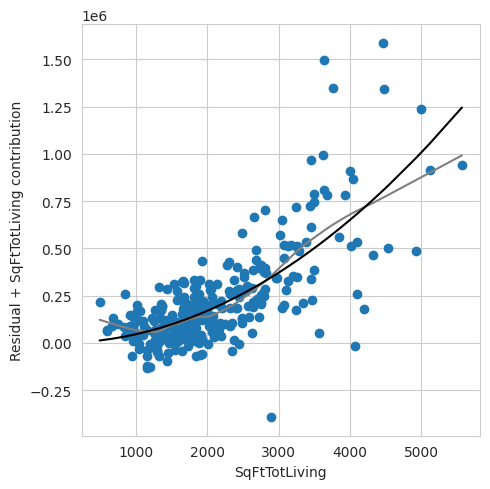

In [28]:
def partialResidualPlot(model, df, outcome, feature, ax):
    y_pred = model.predict(df)
    required = set(model.params.index).intersection(df.columns)
    required.add(feature)
    copy_df = df[list(required)].copy().astype('float')
    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df.loc[:, c] = 0.0
    feature_prediction = model.predict(copy_df)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': df[outcome] - y_pred,
        'ypartial': feature_prediction - model.params.iloc[0],
    })
    results = results.sort_values(by=['feature'])
    smoothed = sm.nonparametric.lowess(results.ypartial + results.residual, results.feature, frac=1/3)
    ax.scatter(results.feature, results.ypartial + results.residual)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='gray')
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature); ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_poly, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)
plt.tight_layout(); plt.show()

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     131.8
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          7.10e-104
Time:                        11:49:56   Log-Likelihood:                -4211.4
No. Observations:                 313   AIC:                             8445.
Df Residuals:                     302   BIC:                             8486.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


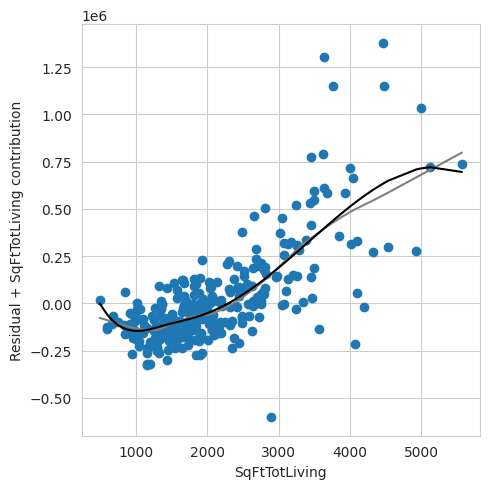

In [29]:
# Spline regression with a B-spline basis
formula = ('AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + SqFtLot + Bathrooms + Bedrooms + BldgGrade')
model_spline = smf.ols(formula=formula, data=house_98105)
result_spline = model_spline.fit()
print(result_spline.summary())

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_spline, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)
plt.tight_layout(); plt.show()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02

 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00

/tmp/ipykernel_585/1800783970.py:7: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6772
Link Function:                     IdentityLink Log Likelihood:                                 -4213.0332
Number of Samples:                          313 AIC:                                             8443.4209
                                                AICc:                                            8443.9746
                                                GCV:                                      30838885095.1675
                                                Scale:                                         171698.5198
                                                Pseudo R-Squared:                                   0.8117
Feature Function                  Lam

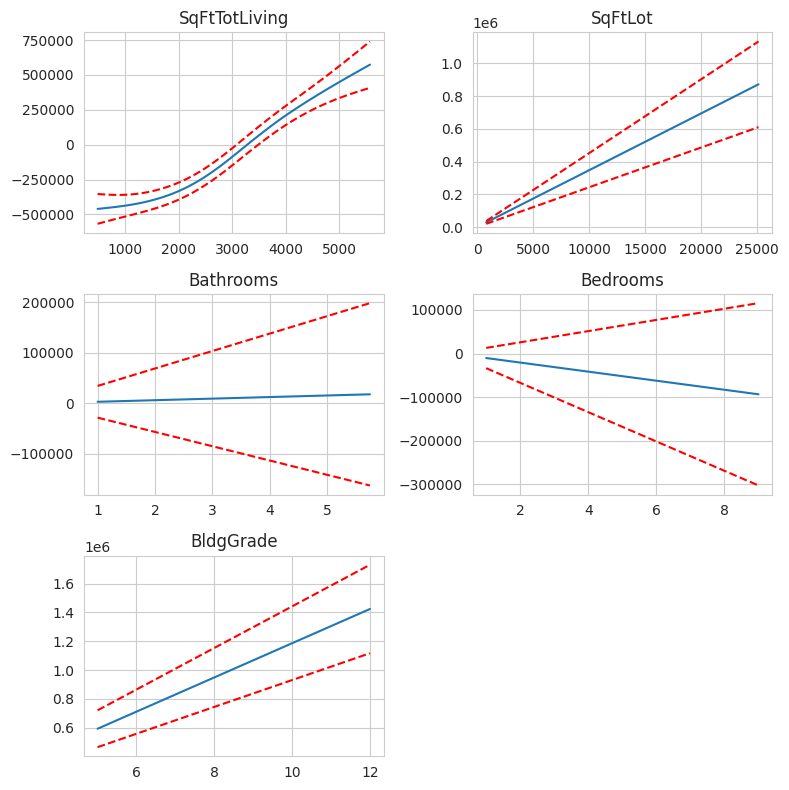

In [30]:
# Generalized additive model
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
X = house_98105[predictors].values
y = house_98105[outcome]
gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4))
gam.gridsearch(X, y)
print(gam.summary())

fig, axes = plt.subplots(figsize=(8, 8), ncols=2, nrows=3)
titles = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
for i, title in enumerate(titles):
    ax = axes[i // 2, i % 2]
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    ax.set_title(title)
axes[2][1].set_visible(False)
plt.tight_layout(); plt.show()

## Tambahan: Regularisasi (Ridge dan Lasso)
**Penjelasan teori.** Regresi dengan penalti mengecilkan koefisien untuk mengurangi overfitting. **Ridge** menambahkan $\lambda\sum b_j^2$, sedangkan **Lasso** menambahkan $\lambda\sum|b_j|$ dan bisa membuat sebagian koefisien persis nol (sekaligus melakukan seleksi variabel). Prediktor harus distandarkan dulu, dan $\lambda$ dipilih lewat cross-validation. Bagian ini bukan inti bab, tetapi berkaitan dengan trade-off bias dan varians di Bab 6.

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade',
              'NbrLivingUnits', 'SqFtFinBasement', 'YrBuilt', 'YrRenovated']
Xs = StandardScaler().fit_transform(house[predictors].astype(float))
lasso = LassoCV(cv=5, random_state=1).fit(Xs, house['AdjSalePrice'])
ridge = RidgeCV(alphas=np.logspace(-2, 4, 30)).fit(Xs, house['AdjSalePrice'])
print(pd.DataFrame({'lasso': lasso.coef_, 'ridge': ridge.coef_}, index=predictors).round(0))

                    lasso     ridge
SqFtTotLiving    169696.0  169453.0
SqFtLot             653.0    1614.0
Bathrooms         34865.0   37703.0
Bedrooms         -47383.0  -49584.0
BldgGrade        165770.0  166111.0
NbrLivingUnits       -0.0    -867.0
SqFtFinBasement    5909.0    6512.0
YrBuilt         -100347.0 -102302.0
YrRenovated           0.0    -304.0


## Poin Penting
- Regresi linear dipasang dengan kuadrat terkecil. $R^2$, RMSE, dan cross-validation dipakai untuk menilainya, sedangkan AIC dan stepwise membantu memilih model.
- Variabel faktor perlu di-dummy-kan, dan prediktor yang berkorelasi serta confounder membuat interpretasi lebih rumit.
- Diagnostik (outlier, leverage, Cook's distance, heteroskedastisitas, partial residual) menunjukkan di mana model bermasalah.
- Polinomial, spline, dan GAM bisa menangkap hubungan non-linear tanpa membuat model sulit ditafsirkan.